# Entrega Clustering Grupo 16

Integrantes:
- Eduardo Montecinos
- Jose Silva
- Matías Toledo

In [91]:
library(cluster)
options(scipen = 999)

## Ejercicio 1:
### De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.

      V1    V2    V3    V4    V5    V6
1  16.63 15.46 6.053 3.465 2.040 5.877
2  20.03 16.90 6.493 3.857 3.063 6.320
3  15.60 15.11 5.832 3.286 2.725 5.752
4  10.82 12.83 5.180 2.630 4.853 5.089
5  14.79 14.52 5.545 3.291 2.704 5.111
6  14.03 14.16 5.438 3.201 1.717 5.001
7  16.44 15.25 5.884 3.505 1.969 5.533
8  13.78 14.06 5.479 3.156 3.136 4.872
9  18.76 16.20 6.172 3.796 3.120 6.053
10 12.88 13.50 5.139 3.119 2.352 4.607


       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

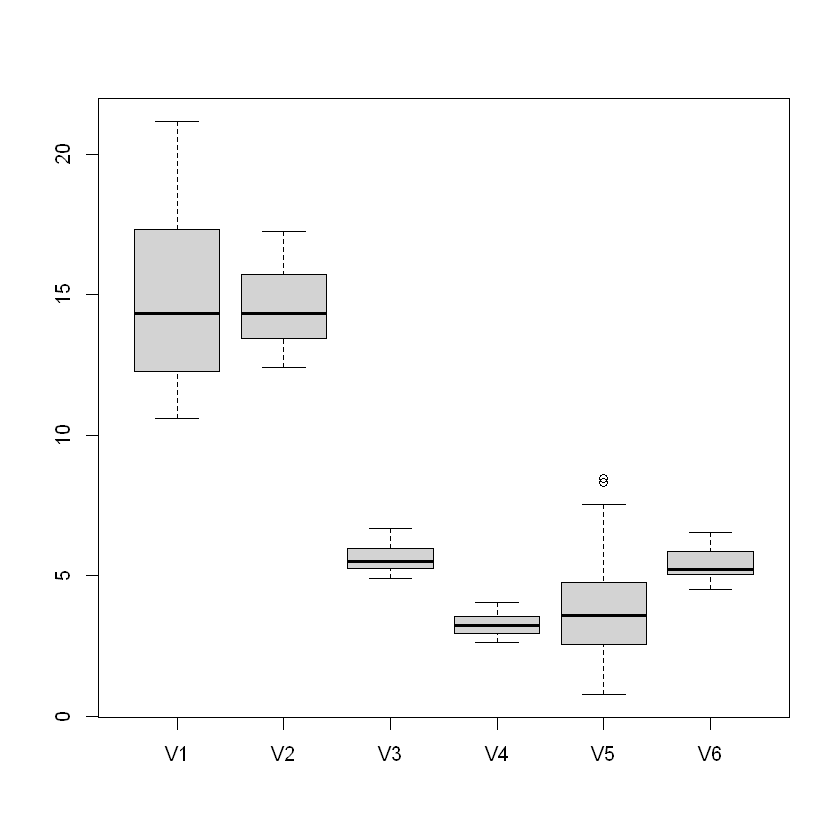

In [92]:
# Carga datos Ejercicio 1
#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos1 <- read.table("semillas1.txt", dec = ".")

print(datos1[1:10,])
summary(datos1)
boxplot(datos1)

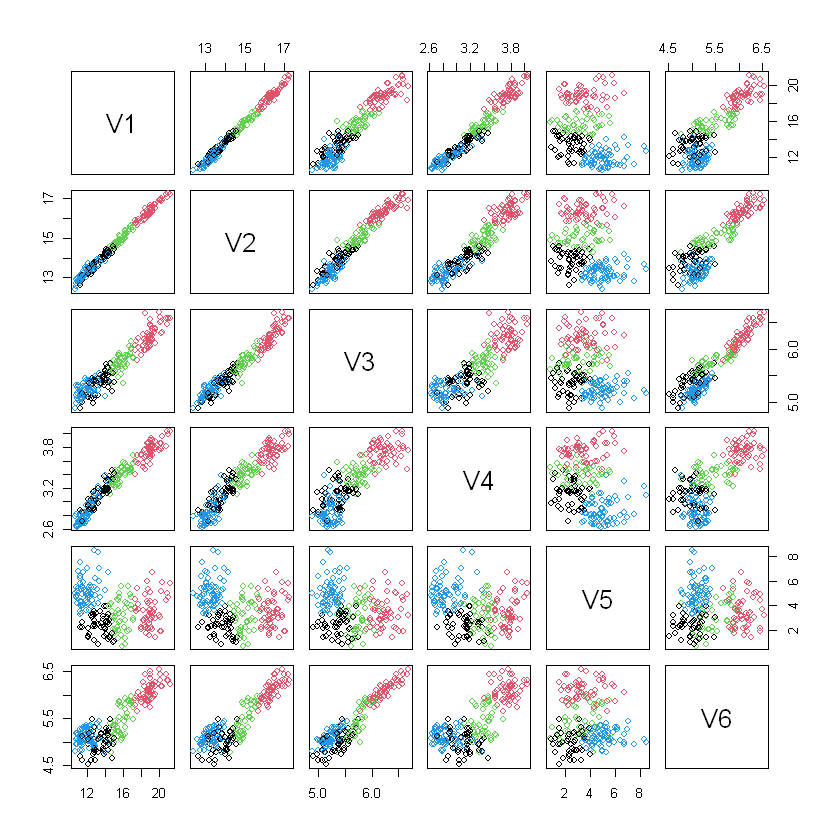

In [93]:
#ingresar valor de k0 
k0=4
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,-1.1731198,1.0501576,0.10256003,0.05800065,-0.0041432679,0.001410480
2,3.0936321,-0.2499533,-0.04446158,-0.04386905,0.0115749668,0.013458399
3,0.6362517,0.3177031,0.12251442,0.05021075,-0.0084876163,-0.025890456
4,-2.1376924,-0.7392228,-0.11677986,-0.03800567,-0.0009242843,0.005265824


K-means clustering with 4 clusters of sizes 46, 54, 44, 66

Cluster means:
        V1       V2       V3       V4       V5       V6
1 13.39109 13.86522 5.366000 3.114283 2.415804 4.990674
2 18.96296 16.39667 6.242722 3.749926 3.540333 6.100778
3 15.71909 14.97659 5.745182 3.398500 3.187045 5.448386
4 11.91439 13.26152 5.231227 2.863939 5.068288 5.105348

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  3   2   3   4   3   1   3   1   2   1   4   3   3   3   2   4   4   3   3   4 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  4   2   3   4   4   3   4   1   1   2   3   1   4   3   2   2   2   4   3   4 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  1   4   2   1   4   2   2   4   4   4   2   1   3   4   3   1   3   3   2   4 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  1   2   1   3   2   1   2   3   2   4   2   1   3   2   

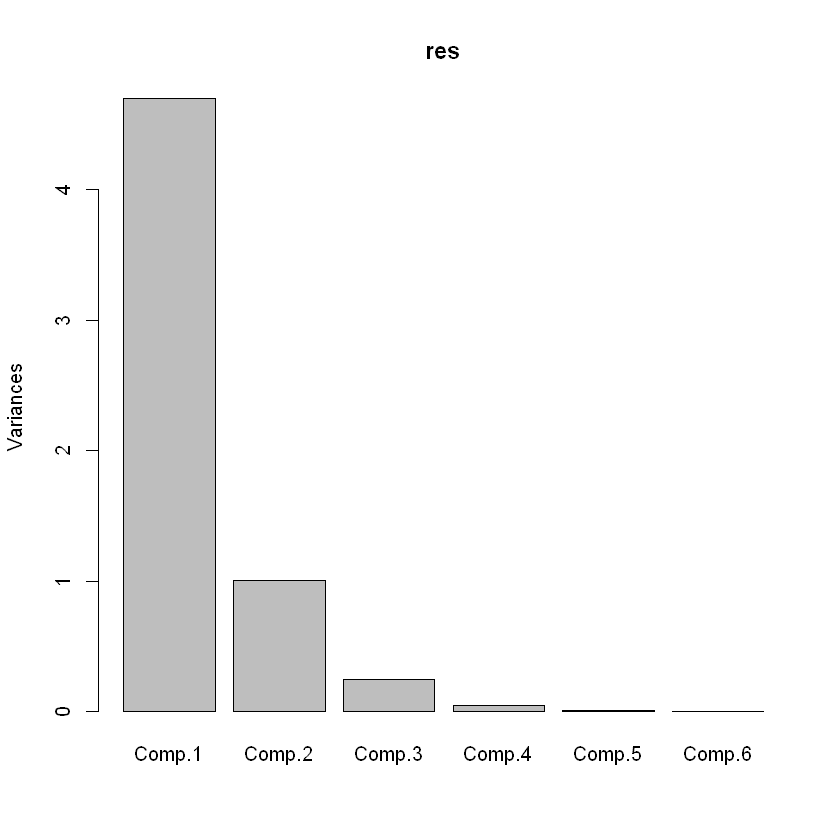

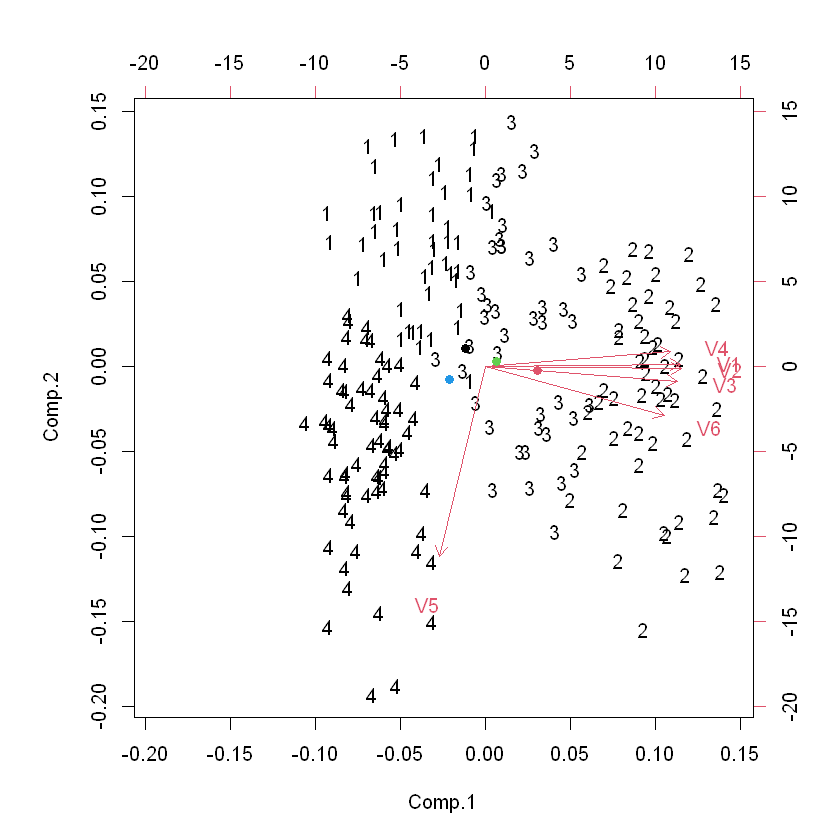

In [94]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

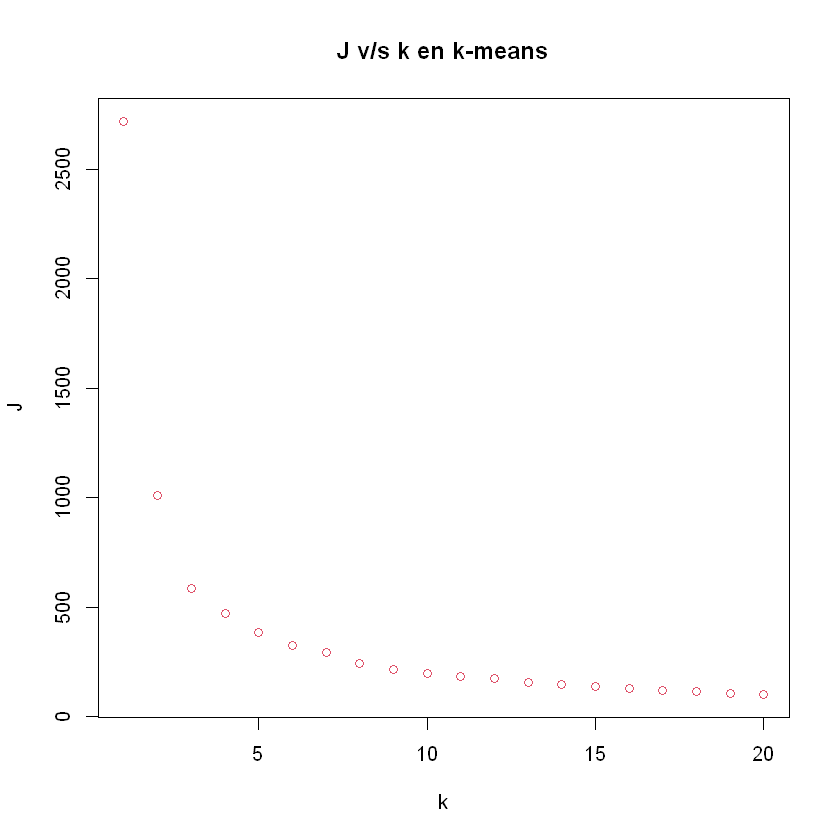

In [8]:
#Estrategia para elegir K, el numero de grupos
#J suma cuadrado de las distancias por cada k utilizado
#K-means
J<-rep(0,20)
fin_iter<-20


for (k in 1:fin_iter){
     cl<-kmeans(datos1,k,iter.max=1000,nstart=10)
	 J[k]<-cl$tot.withinss
}


plot(1:fin_iter,J,xlab="k",ylab="J",type="p",main="J v/s k en k-means",col=2) 

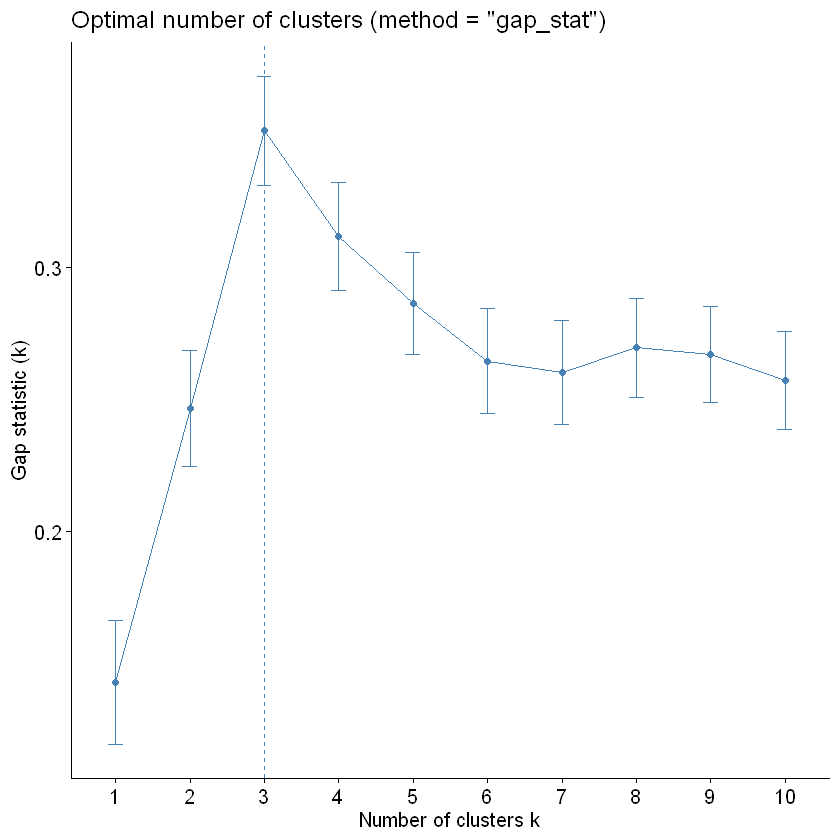

In [77]:
df1 <- data.frame(datos1)
gap_stat <- clusGap(df1,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

K = 3 es el óptimo por codo y gap_stat

## Pregunta 2
### Realice nuevamente los cálculos con el K óptimo y  caracterice los grupos obtenidos. Interprete sus resultados

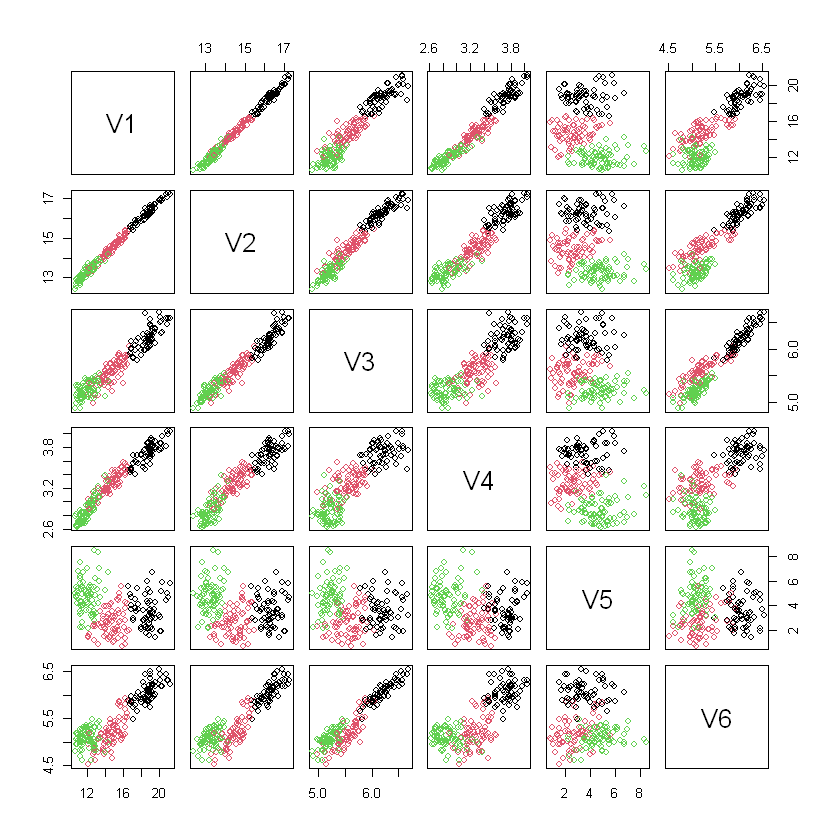

In [87]:
#ingresar valor de k0 
k_opt1 <- 3
cl<-kmeans(datos1,k_opt1,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,2.9205042,-0.2730151,-0.03930464,-0.04246970,0.010152392,0.007972724
2,-0.2189232,0.7985683,0.16423218,0.08015012,-0.010906320,-0.014971476
3,-2.1089388,-0.5304285,-0.12243032,-0.04130075,0.002155313,0.007683248


K-means clustering with 3 clusters of sizes 61, 72, 77

Cluster means:
        V1       V2       V3       V4       V5       V6
1 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098
2 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319
3 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  2   1   2   3   2   2   2   2   1   2   3   2   2   1   1   3   3   2   2   3 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  3   1   2   3   3   1   3   2   2   1   2   2   3   2   1   1   1   3   2   3 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  3   3   1   2   3   1   1   3   3   3   1   3   2   3   2   2   1   2   1   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  2   1   3   2   1   2   1   2   1   3   1   2   2   1   2   1   2   1   2   1 
 81  82  83  84  85  86  87  88  89  

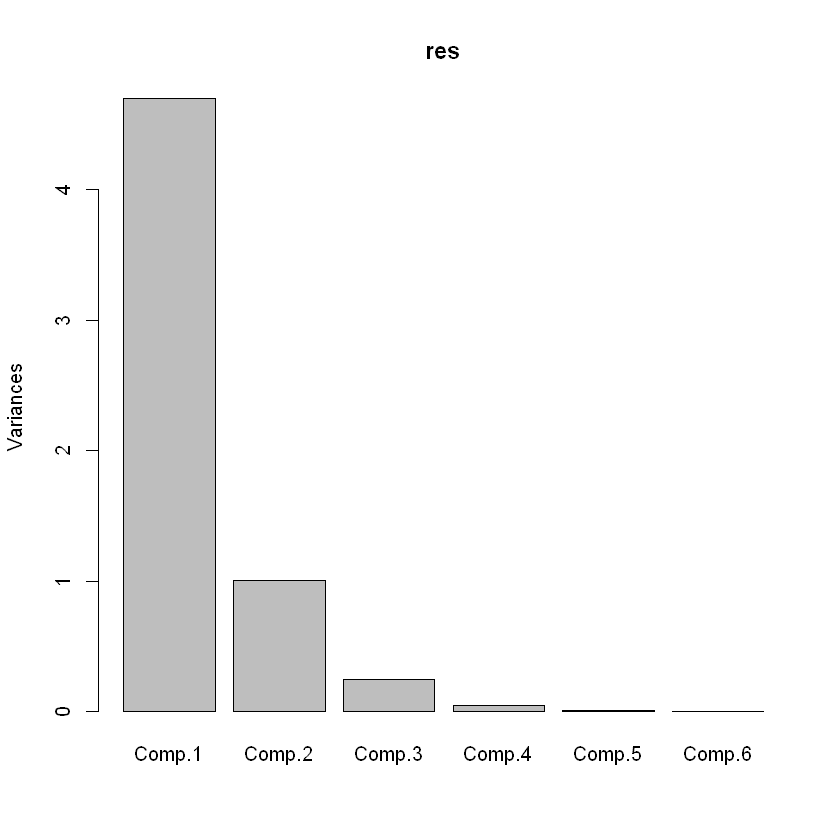

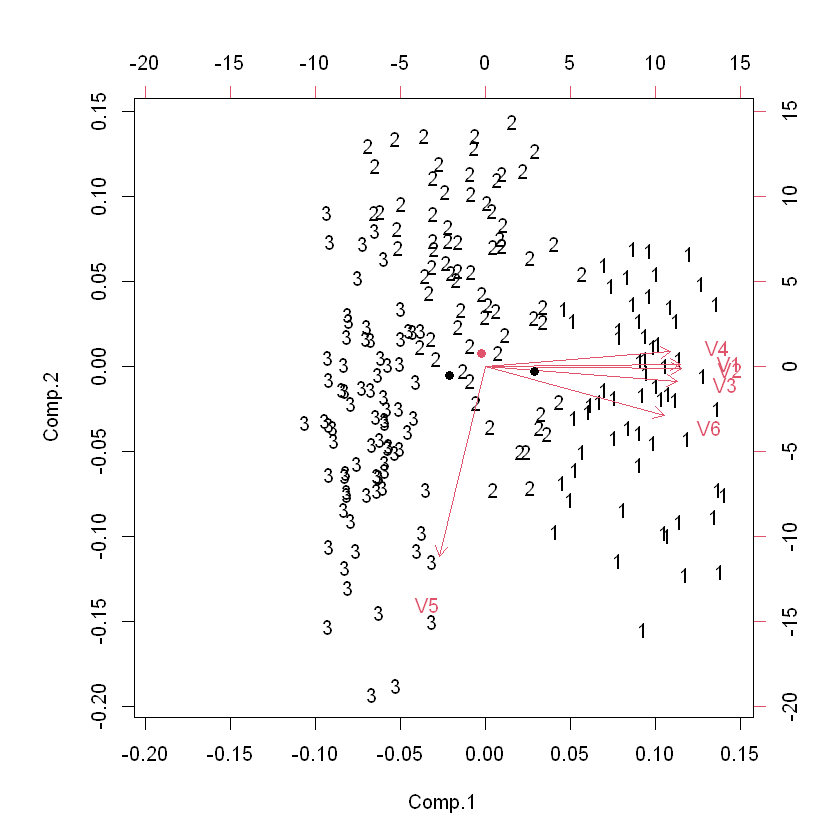

In [88]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

In [89]:
# K-means con k optimo (cambiar segun el grafico anterior)
cl1 <- kmeans(datos1, k_opt1, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl1$centers)
cat("\nTamaño de los grupos:\n")
print(table(cl1$cluster))

Centros de los grupos:
        V1       V2       V3       V4       V5       V6
1 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519
2 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319
3 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098

Tamaño de los grupos:

 1  2  3 
77 72 61 


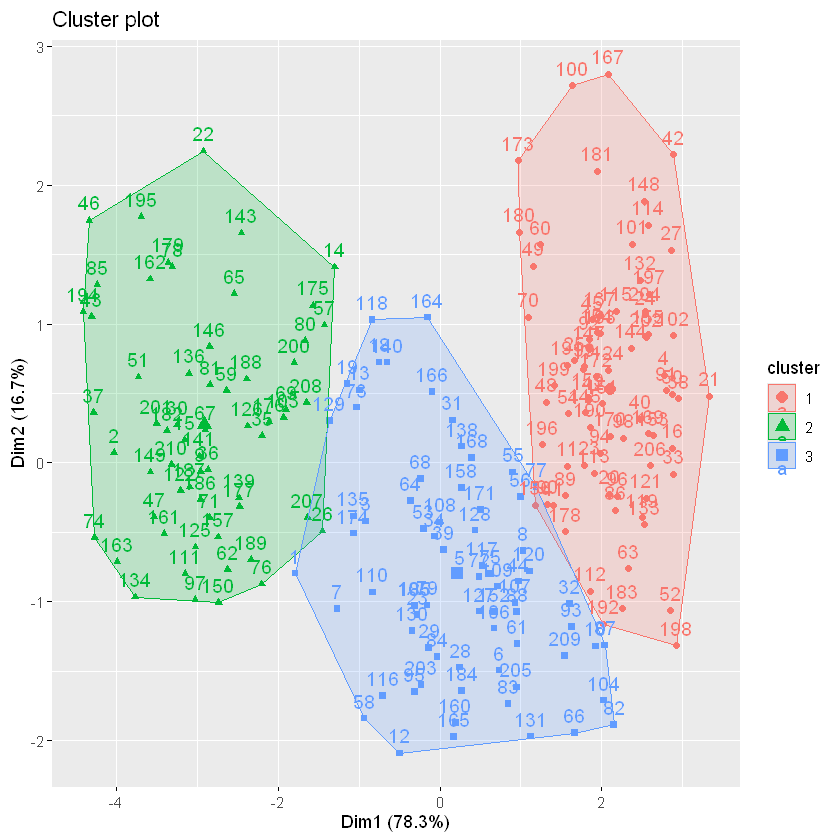

In [90]:
#install.packages("factoextra")

# 2. Load the library
library(factoextra)

df1 <- data.frame(datos1)
k0=3
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
fviz_cluster(cl, df1)

## Ejercicio 2: Grupo16.csv
## Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

### Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento

   frecuencia  gasto visitas devoluciones satisfaccion_cliente
1        4.30  83.99   38.43         2.84                 0.61
2        8.42  26.05   47.75         1.30                 0.99
3        5.26 139.65   44.99         3.94                 1.38
4        6.22  48.49   30.08         1.50                 2.41
5        1.19  56.70   62.28         1.35                 0.48
6        7.31  49.42   54.64        -0.29                 1.01
7        2.56 117.85   75.88         2.76                 1.49
8        4.33 145.89   47.87         3.76                 1.81
9        6.31  50.82   42.30        -0.65                 1.75
10       2.85  25.60   23.57         1.19                 0.38


   frecuencia         gasto            visitas        devoluciones   
 Min.   :-2.360   Min.   :-189.90   Min.   :-17.90   Min.   :-4.150  
 1st Qu.: 3.450   1st Qu.:  41.20   1st Qu.: 26.34   1st Qu.: 0.975  
 Median : 5.060   Median :  60.62   Median : 42.24   Median : 1.950  
 Mean   : 5.066   Mean   :  62.97   Mean   : 42.74   Mean   : 2.206  
 3rd Qu.: 6.690   3rd Qu.:  83.72   3rd Qu.: 56.57   3rd Qu.: 3.170  
 Max.   :16.490   Max.   : 277.54   Max.   :158.36   Max.   :13.570  
 satisfaccion_cliente
 Min.   :0.010       
 1st Qu.:0.925       
 Median :1.240       
 Mean   :1.467       
 3rd Qu.:1.795       
 Max.   :5.740       

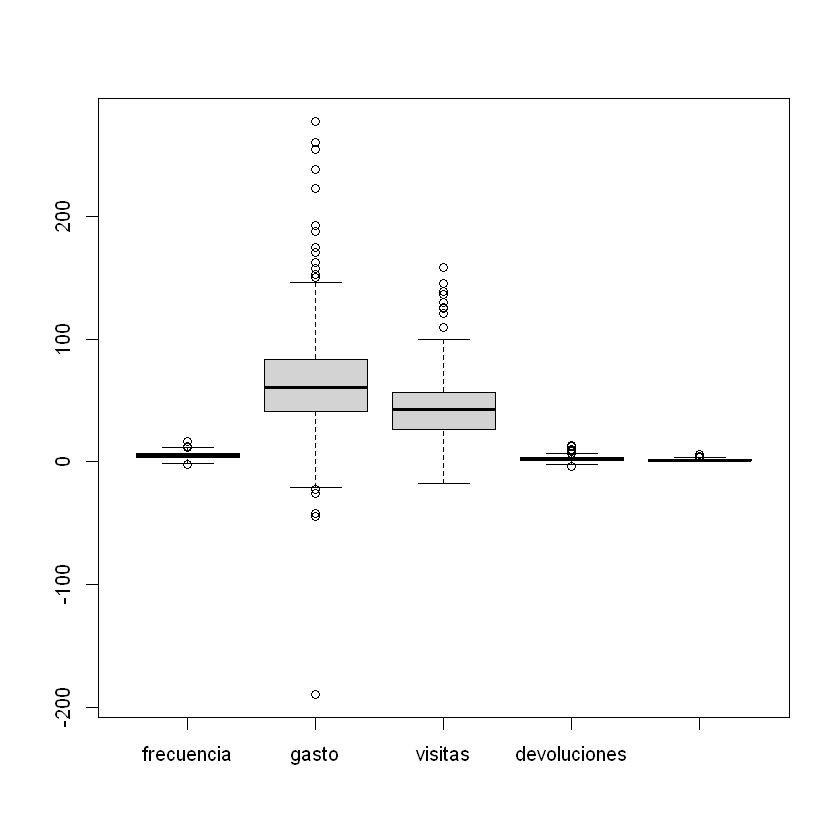

In [107]:
# Carga datos Ejercicio 2 (sin penultima y ultima columna)
datos2_raw <- read.csv("Grupo16.csv", header = TRUE, sep = ";")
datos2 <- datos2_raw[, 1:(ncol(datos2_raw) - 2)]
datos2 <- datos2[, sapply(datos2, is.numeric), drop = FALSE]
datos2 <- datos2[complete.cases(datos2), , drop = FALSE]
print(datos2[1:10,])
summary(datos2)
boxplot(datos2)

### Utilice k-means para realizar el clustering de los datos y calcule el K óptimo.

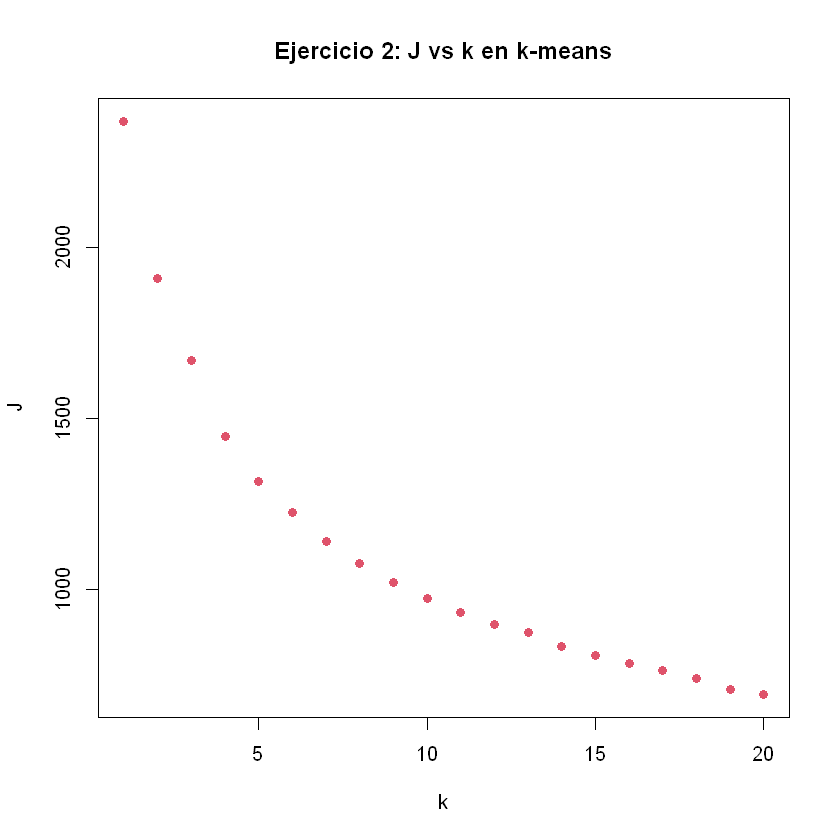

In [53]:
# Grafico J vs k para elegir k optimo
J2 <- rep(0, 20)
fin_iter2 <- 20
for (k in 1:fin_iter2) {
  cl_temp <- kmeans(scaled_df2, k, iter.max = 1000, nstart = 10)
  J2[k] <- cl_temp$tot.withinss
}
plot(1:fin_iter2, J2, xlab = "k", ylab = "J", type = "p",
     main = "Ejercicio 2: J vs k en k-means", col = 2, pch = 19)

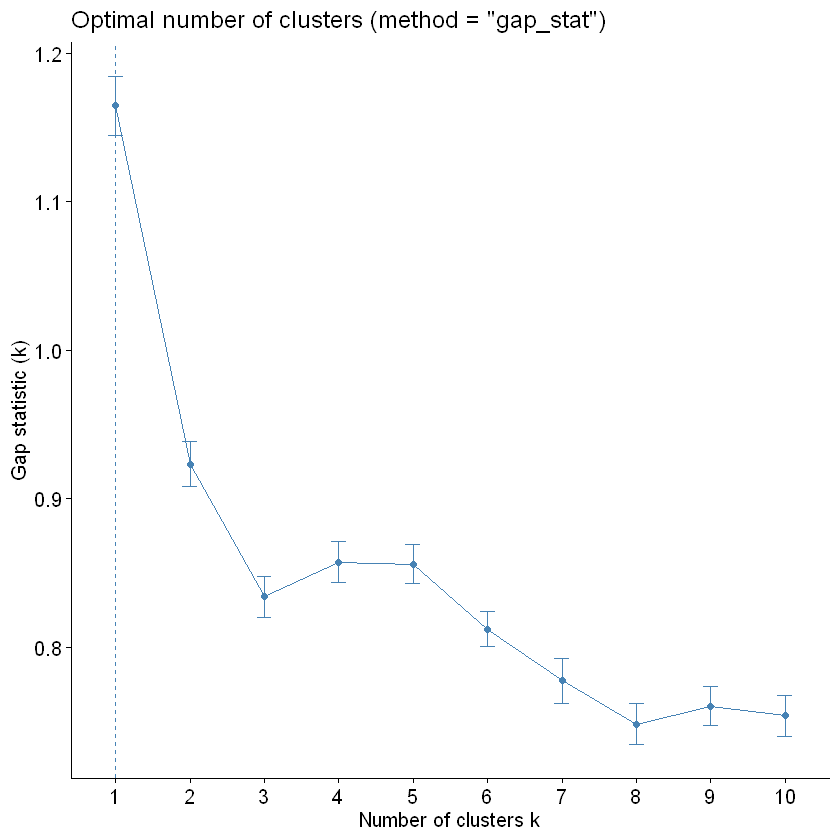

In [72]:
#calculo de gap estadístico basado en el número de grupos: 
#tasa entre la suma de distancias intragrupos con k grupos y con un sólo un grupo
df2 <- data.frame(datos2)
gap_stat <- clusGap(df2,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

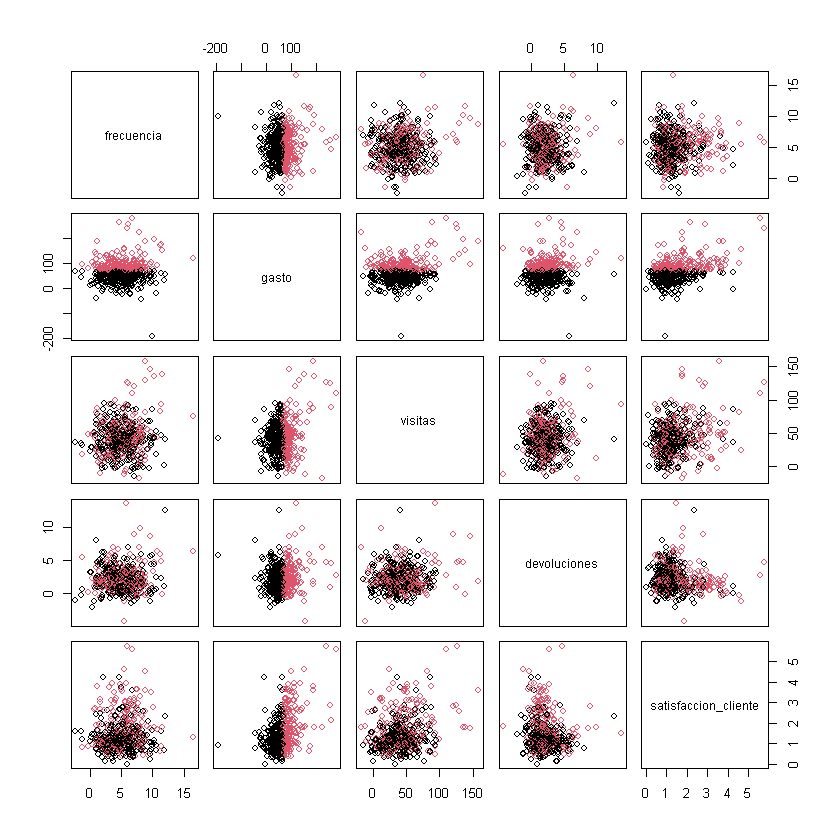

In [103]:
#ingresar valor de k0 
k0=2
cl<-kmeans(datos2,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos2,col=cl$cluster)

# K=1 o k=2 parece ser la mejor opcion

### Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados

Call:
princomp(x = datos2, cor = TRUE)

Standard deviations:
   Comp.1    Comp.2    Comp.3    Comp.4    Comp.5 
1.2760722 1.0549103 0.9768187 0.8795979 0.7286541 

 5  variables and  475 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5
1,-0.5613935,0.008196975,0.1066220,-0.2490063,-0.1429346
2,0.8722727,-0.012736160,-0.1656654,0.3868968,0.2220866


K-means clustering with 2 clusters of sizes 289, 186

Cluster means:
  frecuencia    gasto  visitas devoluciones satisfaccion_cliente
1   4.943114 39.41111 40.28585     2.015225             1.240900
2   5.256667 99.56414 46.56226     2.501183             1.817258

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18  19  21  22 
  2   1   2   1   1   1   2   2   1   1   2   2   2   2   2   1   2   1   1   2 
 23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42 
  1   2   1   2   2   1   2   1   1   1   1   1   1   1   1   1   2   1   1   1 
 43  44  45  46  47  48  49  50  52  53  54  55  56  57  58  59  60  61  62  63 
  1   1   2   2   2   2   1   1   2   1   1   2   1   1   1   2   1   1   1   2 
 64  65  66  67  68  69  70  71  73  74  75  76  77  78  79  80  81  82  83  84 
  1   2   2   2   1   1   1   1   2   1   1   1   1   1   1   1   1   2   1   1 
 85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 

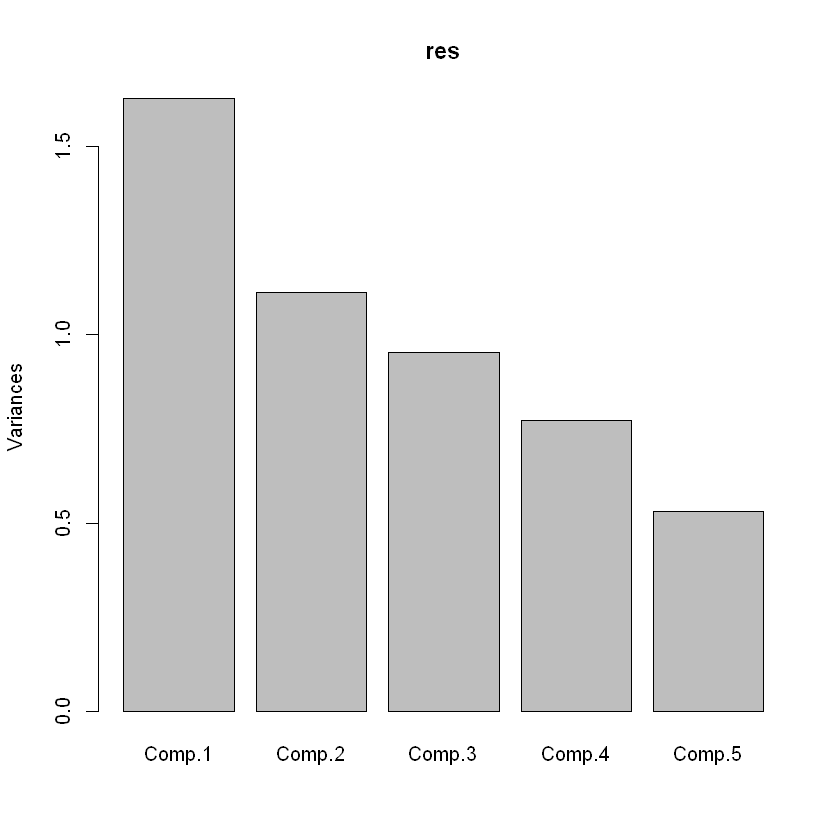

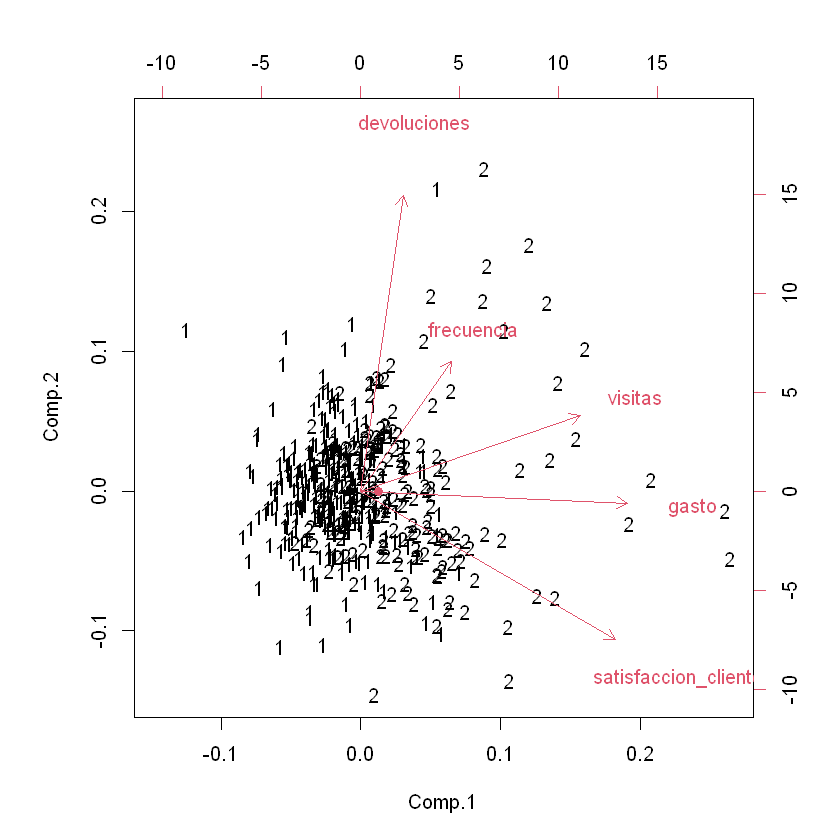

In [104]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos2, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

In [105]:
# K-means con k optimo (cambiar segun el grafico anterior)
k_opt2 <- 2
cl2 <- kmeans(scaled_df2, k_opt2, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl2$centers)
cat("\nTamano de los grupos:\n")
print(table(cl2$cluster))

Centros de los grupos:
  frecuencia      gasto    visitas devoluciones satisfaccion_cliente
1 -0.1255267 -0.2847949 -0.1881528 -0.003612947           -0.4121294
2  0.4021299  0.9123517  0.6027548  0.011574221            1.3202729

Tamano de los grupos:

  1   2 
362 113 


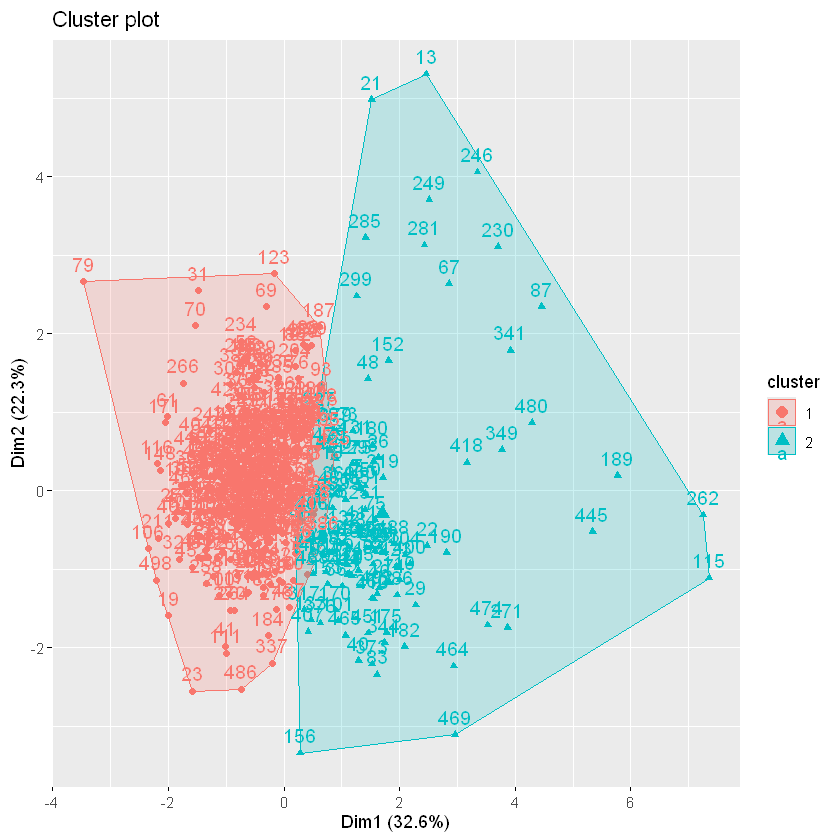

In [106]:
# 2. Load the library
library(factoextra)

df2 <- data.frame(datos2)
fviz_cluster(cl2, df2)